# Importing Required Packages

In [37]:
# Required packages
import pandas as pd  # Load and preprocess data.
import os  # Manage file paths and directories.
import requests  # Send HTTP requests to interact with web APIs or download content from the internet.
import io  # Provides tools for working with I/O streams.
import matplotlib.pyplot as plt  # Create static visualizations like line plots, bar charts, and scatter plots.
import seaborn as sns  # Create enhanced statistical data visualizations like heatmaps and pair plots.
import plotly.express as px  # Quickly create interactive visualizations like scatter plots, line charts, and maps.
import plotly.graph_objects as go  # Build detailed and customized interactive visualizations.
import numpy as np  # Perform numerical operations on arrays and matrices efficiently.
import math  # Perform basic mathematical calculations like logarithms and trigonometric functions.
import ee  # Use Google Earth Engine for large-scale geospatial analysis and satellite data processing.
import scipy.stats as stats  # Perform statistical functions and hypothesis testing.
from sklearn.preprocessing import StandardScaler  # Standardize features by removing the mean and scaling to unit variance.
from sklearn.model_selection import train_test_split  # Split data into training and testing sets for model evaluation.
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor  # Use ensemble methods for regression tasks.
from sklearn.neural_network import MLPRegressor  # Use a Multi-Layer Perceptron model for regression.
from sklearn.svm import SVR  # Use a Support Vector Regressor for regression problems.
from sklearn.metrics import mean_squared_error, r2_score  # Evaluate regression models using metrics like MSE and R².
from sklearn.model_selection import GridSearchCV
from xgboost.sklearn import XGBRegressor
import json

# Importing Data from Github

In [38]:
url = "https://raw.githubusercontent.com/irungus/agf_kenya/main/data/acacia_df_cleaned_agb_14_2_2025.csv"
acacia_df_cleaned_agb = pd.read_csv(url)

In [39]:
acacia_df_cleaned_agb.head()

,FID,start,end,Enumerator,agf,plotID,transect,County,localname,genus,...,KEY,date,height_m,genusCorr,speciesCorr,meanWD,sdWD,family,AGB,genus_species
0,5667,08:21.3,NaN,sarah_mwangi,pasture_agroforestry,22,3,Kwale,Hookthorn,Acacia,...,NaN,05/12/2024,1.8,Acacia,mellifera,0.947000,0.070823,Fabaceae,39.236401,Acacia mellifera
1,5680,20:25.8,NaN,henry_oindi,pasture_agroforestry,22,3,Kwale,Umbrella acacia,Acacia,...,NaN,05/12/2024,13.0,Acacia,tortilis,0.787831,0.094134,Fabaceae,711.287343,Acacia tortilis
2,5652,56:32.0,NaN,henry_oindi,pasture_agroforestry,22,3,Kwale,Scented-pod acacia,Acacia,...,NaN,05/12/2024,7.3,Acacia,nilotica,0.723333,0.070823,Fabaceae,653.304165,Acacia nilotica
3,5664,04:37.0,NaN,henry_oindi,pasture_agroforestry,22,3,Kwale,Scented-pod acacia,Acacia,...,NaN,05/12/2024,4.5,Acacia,nilotica,0.723333,0.070823,Fabaceae,31.818687,Acacia nilotica
4,5656,58:25.4,NaN,henry_oindi,pasture_agroforestry,22,3,Kwale,Scented-pod acacia,Acacia,...,NaN,05/12/2024,1.8,Acacia,nilotica,0.723333,0.070823,Fabaceae,2.876250,Acacia nilotica


# Data Cleaning

In [3]:
#Display the columns of the dataframe
acacia_df_cleaned_agb.columns

Index(['FID', 'start', 'end', 'Enumerator', 'agf', 'plotID', 'transect',
       'County', 'localname', 'genus', 'species', 'newspecies', 'dbh',
       'height', 'canopyd', 'latitude', 'longitude', 'altitude', 'accuracy',
       '__version_', '_version_', 'key', 'KEY', 'date', 'height_m',
       'genusCorr', 'speciesCorr', 'meanWD', 'sdWD', 'family', 'AGB',
       'genus_species'],
      dtype='object')

In [4]:
# Drop unnecessary columns
cols_to_drop = [
    'FID','start','end','Enumerator','agf','plotID','transect','County',
    'localname','genus','species','newspecies','height','canopyd','latitude',
    'longitude','altitude','accuracy','__version_','_version_','key','KEY',
    'date','genusCorr','speciesCorr','sdWD','family'
]

acacia_df_cleaned_agb = acacia_df_cleaned_agb.drop(columns=cols_to_drop, errors='ignore')

# Reorder columns
acacia_df_cleaned_agb = acacia_df_cleaned_agb[['genus_species','dbh', 'height_m','meanWD', 'AGB']]

In [5]:
# Display the first few rows of the cleaned dataframe
acacia_df_cleaned_agb.head()

,genus_species,dbh,height_m,meanWD,AGB
0,Acacia mellifera,20,1.8,0.947000,39.236401
1,Acacia tortilis,36,13.0,0.787831,711.287343
2,Acacia nilotica,48,7.3,0.723333,653.304165
3,Acacia nilotica,13,4.5,0.723333,31.818687
4,Acacia nilotica,6,1.8,0.723333,2.876250


In [6]:
# Display dataframe info
acacia_df_cleaned_agb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   genus_species  850 non-null    object 
 1   dbh            850 non-null    int64  
 2   height_m       850 non-null    float64
 3   meanWD         850 non-null    float64
 4   AGB            850 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 33.3+ KB


In [7]:
# Display summary statistics of the cleaned dataframe
acacia_df_cleaned_agb.describe()

,dbh,height_m,meanWD,AGB
count,850.000000,850.000000,850.000000,850.000000
mean,42.902353,5.288094,0.772008,974.338306
std,35.663968,3.513183,0.065448,2327.387025
min,5.000000,0.800000,0.659667,1.113433
25%,18.250000,2.500000,0.723333,51.913377
50%,32.000000,4.500000,0.787831,204.767951
75%,55.750000,7.000000,0.787831,714.844172
max,200.000000,22.000000,0.947000,23249.279980


In [8]:
# Function to calculate statistics by genus-species
def calculate_stats_by_genus_species(dataframe):
    """
    Calculates the mean, standard deviation, and count of height, dbh, wood density as calcualated
    from Biomass package and AGB the for each unique genus-species combination.
    """
    required_columns = {'genus_species', 'height_m', 'dbh'}
    if not required_columns.issubset(dataframe.columns):
        raise ValueError(f"DataFrame must contain columns: {required_columns}")
    # Group by genus and species
    grouped = dataframe.groupby(['genus_species'])
    # Calculate statistics for height_m and dbh
    stats = grouped.agg(
        count=('genus_species', 'count'),
        height_mean=('height_m', 'mean'),
        height_std=('height_m', 'std'),
        height_min=('height_m', 'min'),
        height_max=('height_m', 'max'),
        dbh_mean=('dbh', 'mean'),
        dbh_std=('dbh', 'std'),
        dbh_min=('dbh', 'min'),
        dbh_max=('dbh', 'max'),
        WoodDensity_mean = ('meanWD', 'mean'),
        AGB_mean=('AGB', 'mean'),
        AGB_std=('AGB', 'std'),
        AGB_min=('AGB', 'min'),
        AGB_max=('AGB', 'max')
    ).reset_index()
    return stats

In [9]:
# Calculate statistics by genus-species
stats_summary_acacia = calculate_stats_by_genus_species(acacia_df_cleaned_agb)
stats_summary_acacia

,genus_species,count,height_mean,height_std,height_min,height_max,dbh_mean,dbh_std,dbh_min,dbh_max,WoodDensity_mean,AGB_mean,AGB_std,AGB_min,AGB_max
0,Acacia drepanolobium,138,3.445290,1.842462,0.8,8.5,25.768116,21.786385,5,120,0.787831,184.714302,353.262078,1.113433,2943.514584
1,Acacia mearnsii,103,7.309709,3.190166,1.0,20.0,46.466019,35.494771,5,190,0.659667,983.103737,1574.388882,2.041129,9576.761484
2,Acacia mellifera,63,3.102540,1.920459,0.9,8.0,35.476190,37.120057,5,200,0.947000,351.195782,815.738057,2.336378,5783.803635
3,Acacia nilotica,114,4.044737,2.953065,1.0,19.0,28.885965,19.475766,5,110,0.723333,321.260992,885.823825,1.135322,7955.617717
4,Acacia tortilis,334,5.285240,3.173127,1.0,20.0,49.071856,35.337764,5,200,0.787831,1170.559391,2599.983199,1.234023,23249.279980
5,Acacia xanthophloea,98,8.619388,4.488597,1.0,22.0,63.336735,47.718017,5,200,0.758000,2568.585487,3967.427724,3.472418,19471.144160


In [77]:
# stats_summary_acacia.to_csv('statsbygenus.csv', index=True)

# Define Traditional Models

In [18]:
# Allometric equations
def agb_brown_1989(dbh, height):
    return np.exp(-3.1141 + 0.9719 * np.log((dbh ** 2) * height))
def agb_chave_2005(dbh, height, wd):
    return np.exp(-2.187 + 0.916 * np.log((dbh ** 2) * height * wd))
def agb_henry_20O9(dbh, height):
    return 0.051 * ((dbh ** 2) * height) ** 0.930

In [19]:
def compute_traditional_models(group):
    group['AGB_Brown'] = group.apply(lambda x: agb_brown_1989(x['dbh'], x['height_m']), axis=1)
    group['AGB_Chave2005'] = group.apply(lambda x: agb_chave_2005(x['dbh'], x['height_m'], x['meanWD']), axis=1)
    group['AGB_Henry'] = group.apply(lambda x: agb_henry_20O9(x['dbh'], x['height_m']), axis=1)
    return group

In [20]:
# Loop through all the species
for species, group in acacia_df_cleaned_agb.groupby('genus_species'):
    group = compute_traditional_models(group)
# Compute metrics for traditional models
    metrics = {
      "Species": species,
      "Chave et al. (2005) RMSE": np.sqrt(mean_squared_error(group['AGB'], group['AGB_Chave2005'])),
      "Chave et al. (2005) R²": r2_score(group['AGB'], group['AGB_Chave2005']),
      "Chave et al. (2005) rRMSE%": (
          np.sqrt(mean_squared_error(group['AGB'], group['AGB_Chave2005'])) / group['AGB'].mean()
      ) * 100,

      "Brown et al. (1989) RMSE": np.sqrt(mean_squared_error(group['AGB'], group['AGB_Brown'])),
      "Brown et al. (1989) R²": r2_score(group['AGB'], group['AGB_Brown']),
      "Brown et al. (1989) rRMSE%": (
          np.sqrt(mean_squared_error(group['AGB'], group['AGB_Brown'])) / group['AGB'].mean()
      ) * 100,

      "Henry et al. (2009) RMSE": np.sqrt(mean_squared_error(group['AGB'], group['AGB_Henry'])),
      "Henry et al. (2009) R²": r2_score(group['AGB'], group['AGB_Henry']),
      "Henry et al. (2009) rRMSE%": (
          np.sqrt(mean_squared_error(group['AGB'], group['AGB_Henry'])) / group['AGB'].mean()
      ) * 100,
}

 # Embed AGB predictions directly into the original dataframe
    acacia_df_cleaned_agb.loc[group.index, 'AGB_Chave2005'] = group['AGB_Chave2005']
    acacia_df_cleaned_agb.loc[group.index, 'AGB_Brown'] = group['AGB_Brown']
    acacia_df_cleaned_agb.loc[group.index, 'AGB_Henry'] = group['AGB_Henry']

    # Print individual species results
    print(f"Results for {species}:")
    for key, value in metrics.items():
        print(f"  {key}: {value}")
    print("-" * 50)

# Print completion message
print("Traditional model evaluation complete. Results embedded in the original dataset.")

Results for Acacia drepanolobium:
  Species: Acacia drepanolobium
  Chave et al. (2005) RMSE: 41.31978796248708
  Chave et al. (2005) R²: 0.9862190026844028
  Chave et al. (2005) rRMSE%: 22.36956616304086
  Brown et al. (1989) RMSE: 80.21720139349094
  Brown et al. (1989) R²: 0.9480602933686223
  Brown et al. (1989) rRMSE%: 43.42771544749382
  Henry et al. (2009) RMSE: 161.93495415685518
  Henry et al. (2009) R²: 0.7883366404516744
  Henry et al. (2009) rRMSE%: 87.66779428804028
--------------------------------------------------
Results for Acacia mearnsii:
  Species: Acacia mearnsii
  Chave et al. (2005) RMSE: 303.86150179496684
  Chave et al. (2005) R²: 0.9623847125827163
  Chave et al. (2005) rRMSE%: 30.908386391274696
  Brown et al. (1989) RMSE: 104.55349729347238
  Brown et al. (1989) R²: 0.9955466159061787
  Brown et al. (1989) rRMSE%: 10.635042194605731
  Henry et al. (2009) RMSE: 631.5100486070835
  Henry et al. (2009) R²: 0.8375298596622937
  Henry et al. (2009) rRMSE%: 64.236

In [21]:
# Small constant to avoid division by zero in MAPE
eps = 1e-6

# Loop through all the species
for species, group in acacia_df_cleaned_agb.groupby('genus_species'):
    
    group = compute_traditional_models(group)

    # Compute metrics for traditional models
    metrics = {
        "Species": species,

        # --- Chave et al. (2005) ---
        "Chave et al. (2005) RMSE": np.sqrt(
            mean_squared_error(group['AGB'], group['AGB_Chave2005'])
        ),
        "Chave et al. (2005) R²": r2_score(
            group['AGB'], group['AGB_Chave2005']
        ),
        "Chave et al. (2005) rRMSE%": (
            np.sqrt(mean_squared_error(group['AGB'], group['AGB_Chave2005']))
            / group['AGB'].mean()
        ) * 100,
        "Chave et al. (2005) MAPE%": np.mean(
            np.abs(
                (group['AGB'] - group['AGB_Chave2005'])
                / np.maximum(group['AGB'], eps)
            )
        ) * 100,

        # --- Brown et al. (1989) ---
        "Brown et al. (1989) RMSE": np.sqrt(
            mean_squared_error(group['AGB'], group['AGB_Brown'])
        ),
        "Brown et al. (1989) R²": r2_score(
            group['AGB'], group['AGB_Brown']
        ),
        "Brown et al. (1989) rRMSE%": (
            np.sqrt(mean_squared_error(group['AGB'], group['AGB_Brown']))
            / group['AGB'].mean()
        ) * 100,
        "Brown et al. (1989) MAPE%": np.mean(
            np.abs(
                (group['AGB'] - group['AGB_Brown'])
                / np.maximum(group['AGB'], eps)
            )
        ) * 100,

        # --- Henry et al. (2009) ---
        "Henry et al. (2009) RMSE": np.sqrt(
            mean_squared_error(group['AGB'], group['AGB_Henry'])
        ),
        "Henry et al. (2009) R²": r2_score(
            group['AGB'], group['AGB_Henry']
        ),
        "Henry et al. (2009) rRMSE%": (
            np.sqrt(mean_squared_error(group['AGB'], group['AGB_Henry']))
            / group['AGB'].mean()
        ) * 100,
        "Henry et al. (2009) MAPE%": np.mean(
            np.abs(
                (group['AGB'] - group['AGB_Henry'])
                / np.maximum(group['AGB'], eps)
            )
        ) * 100,
    }

    # Embed AGB predictions directly into the original dataframe
    acacia_df_cleaned_agb.loc[group.index, 'AGB_Chave2005'] = group['AGB_Chave2005']
    acacia_df_cleaned_agb.loc[group.index, 'AGB_Brown'] = group['AGB_Brown']
    acacia_df_cleaned_agb.loc[group.index, 'AGB_Henry'] = group['AGB_Henry']

    # Print individual species results
    print(f"Results for {species}:")
    for key, value in metrics.items():
        print(f"  {key}: {value}")
    print("-" * 50)

# Print completion message
print("Traditional model evaluation complete. Results embedded in the original dataset.")


Results for Acacia drepanolobium:
  Species: Acacia drepanolobium
  Chave et al. (2005) RMSE: 41.31978796248708
  Chave et al. (2005) R²: 0.9862190026844028
  Chave et al. (2005) rRMSE%: 22.36956616304086
  Chave et al. (2005) MAPE%: 13.745096659793516
  Brown et al. (1989) RMSE: 80.21720139349094
  Brown et al. (1989) R²: 0.9480602933686223
  Brown et al. (1989) rRMSE%: 43.42771544749382
  Brown et al. (1989) MAPE%: 19.046137257832985
  Henry et al. (2009) RMSE: 161.93495415685518
  Henry et al. (2009) R²: 0.7883366404516744
  Henry et al. (2009) rRMSE%: 87.66779428804028
  Henry et al. (2009) MAPE%: 30.29883660199274
--------------------------------------------------
Results for Acacia mearnsii:
  Species: Acacia mearnsii
  Chave et al. (2005) RMSE: 303.86150179496684
  Chave et al. (2005) R²: 0.9623847125827163
  Chave et al. (2005) rRMSE%: 30.908386391274696
  Chave et al. (2005) MAPE%: 9.794322534901227
  Brown et al. (1989) RMSE: 104.55349729347238
  Brown et al. (1989) R²: 0.995

# RANDOM FOREST

In [23]:
#------------With best parameters only RF---------------


species_best_params = {
    "Acacia drepanolobium": {
        "bootstrap": True,
        "max_depth": 10,
        "max_features": "sqrt",
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "n_estimators": 50
    },
    "Acacia mearnsii": {
        "bootstrap": True,
        "max_depth": 12,
        "max_features": "sqrt",
        "min_samples_leaf": 1,
        "min_samples_split": 5,
        "n_estimators": 50
    },
    "Acacia mellifera": {
        "bootstrap": True,
        "max_depth": 12,
        "max_features": "sqrt",
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "n_estimators": 50
    },
    "Acacia nilotica": {
        "bootstrap": False,
        "max_depth": 12,
        "max_features": "sqrt",
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "n_estimators": 50
    },
    "Acacia tortilis": {
        "bootstrap": True,
        "max_depth": 12,
        "max_features": "log2",
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "n_estimators": 50
    },
    "Acacia xanthophloea": {
        "bootstrap": True,
        "max_depth": 12,
        "max_features": 0.5,
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "n_estimators": 600
    }
}

results = []

# Small constant to avoid division by zero in MAPE
eps = 1e-6

for species, group in acacia_df_cleaned_agb.groupby('genus_species'):
    X = group[['dbh', 'height_m']]
    y = group['AGB']

    if species not in species_best_params:
        print(f"⚠️ Skipping {species}, no best parameters found.")
        continue

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Initialize species-specific RF
    rf_model = RandomForestRegressor(
        **species_best_params[species],
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)

    # Predictions
    y_pred_train = rf_model.predict(X_train)
    y_pred_test = rf_model.predict(X_test)

    # ---------- Training metrics ----------
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    r2_train = r2_score(y_train, y_pred_train)
    rrmse_train = (rmse_train / np.mean(y_train)) * 100
    mape_train = np.mean(
        np.abs((y_train - y_pred_train) / np.maximum(y_train, eps))
    ) * 100

    # ---------- Test metrics ----------
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test = r2_score(y_test, y_pred_test)
    rrmse_test = (rmse_test / np.mean(y_test)) * 100
    mape_test = np.mean(
        np.abs((y_test - y_pred_test) / np.maximum(y_test, eps))
    ) * 100

    # Store predictions in df
    acacia_df_cleaned_agb.loc[group.index, 'RF_Predicted_AGB2'] = rf_model.predict(X)

    # Collect results
    results.append({
        "Species": species,
        "Train_RMSE": rmse_train,
        "Train_rRMSE%": rrmse_train,
        "Train_MAPE%": mape_train,
        "Train_R²": r2_train,
        "Test_RMSE": rmse_test,
        "Test_rRMSE%": rrmse_test,
        "Test_MAPE%": mape_test,
        "Test_R²": r2_test,
        "Best_Params": species_best_params[species]
    })

    # Print
    print(f"Species: {species}")
    print(
        f" Train RMSE: {rmse_train:.4f}, "
        f"rRMSE%: {rrmse_train:.2f}%, "
        f"MAPE%: {mape_train:.2f}%, "
        f"R²: {r2_train:.4f}"
    )
    print(
        f" Test RMSE: {rmse_test:.4f}, "
        f"rRMSE%: {rrmse_test:.2f}%, "
        f"MAPE%: {mape_test:.2f}%, "
        f"R²: {r2_test:.4f}"
    )
    print(f" ✅ Params used: {species_best_params[species]}")
    print("-" * 50)

# Summary table
metrics_df = pd.DataFrame(results)
print(metrics_df.head())


Species: Acacia drepanolobium
 Train RMSE: 77.1720, rRMSE%: 41.62%, MAPE%: 9.98%, R²: 0.9571
 Test RMSE: 48.0339, rRMSE%: 26.41%, MAPE%: 27.20%, R²: 0.9647
 ✅ Params used: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
--------------------------------------------------
Species: Acacia mearnsii
 Train RMSE: 432.8239, rRMSE%: 44.83%, MAPE%: 141.51%, R²: 0.9321
 Test RMSE: 139.5979, rRMSE%: 13.28%, MAPE%: 63.66%, R²: 0.9845
 ✅ Params used: {'bootstrap': True, 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
--------------------------------------------------
Species: Acacia mellifera
 Train RMSE: 217.2620, rRMSE%: 55.28%, MAPE%: 21.53%, R²: 0.9413
 Test RMSE: 108.5210, rRMSE%: 57.06%, MAPE%: 58.09%, R²: 0.7431
 ✅ Params used: {'bootstrap': True, 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


# GRADIENT BOOSTING 

In [24]:
#------------With best parameters only GB---------------
# Relative RMSE (%)
def rrmse(y_true, y_pred):
    return (np.sqrt(mean_squared_error(y_true, y_pred)) / np.mean(y_true)) * 100

# Mean Absolute Percentage Error (%)
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


# ================== Best Hyperparameters ==================
best_params_dict = {
    "Acacia drepanolobium": {
        'learning_rate': 0.1,
        'max_depth': 3,
        'max_features': 'sqrt',
        'min_samples_leaf': 2,
        'min_samples_split': 2,
        'n_estimators': 200,
        'subsample': 0.8
    },
    "Acacia mearnsii": {
        'learning_rate': 0.1,
        'max_depth': 5,
        'max_features': 'sqrt',
        'min_samples_leaf': 2,
        'min_samples_split': 5,
        'n_estimators': 200,
        'subsample': 0.8
    },
    "Acacia mellifera": {
        'learning_rate': 0.1,
        'max_depth': 3,
        'max_features': 'sqrt',
        'min_samples_leaf': 1,
        'min_samples_split': 5,
        'n_estimators': 200,
        'subsample': 1.0
    },
    "Acacia nilotica": {
        'learning_rate': 0.1,
        'max_depth': 2,
        'max_features': 'sqrt',
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'n_estimators': 600,
        'subsample': 1.0
    },
    "Acacia tortilis": {
        'learning_rate': 0.1,
        'max_depth': 2,
        'max_features': 'sqrt',
        'min_samples_leaf': 1,
        'min_samples_split': 5,
        'n_estimators': 600,
        'subsample': 0.8
    },
    "Acacia xanthophloea": {
        'learning_rate': 0.1,
        'max_depth': 5,
        'max_features': 'sqrt',
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'n_estimators': 200,
        'subsample': 0.8
    }
}

# ================== Model Training & Evaluation ==================

results = []

for species, group in acacia_df_cleaned_agb.groupby("genus_species"):

    if species not in best_params_dict:
        print(f"Skipping {species}, no saved parameters found.")
        continue

    # Features and target
    X = group[["dbh", "height_m"]]
    y = group["AGB"]

    # Train-test split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Initialize Gradient Boosting model
    gb_model = GradientBoostingRegressor(
        random_state=42, **best_params_dict[species]
    )

    # Train model
    gb_model.fit(X_train, y_train)

    # ================== Training Metrics ==================
    train_preds = gb_model.predict(X_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
    r2_train = r2_score(y_train, train_preds)
    rrmse_train = rrmse(y_train, train_preds)
    mape_train = mape(y_train, train_preds)

    # ================== Testing Metrics ==================
    test_preds = gb_model.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))
    r2_test = r2_score(y_test, test_preds)
    rrmse_test = rrmse(y_test, test_preds)
    mape_test = mape(y_test, test_preds)

    # Store predictions for full dataset
    acacia_df_cleaned_agb.loc[group.index, "GB_Predicted_AGB1"] = gb_model.predict(X)

    # Save results
    results.append({
        "Species": species,
        "Train_RMSE": rmse_train,
        "Train_R2": r2_train,
        "Train_rRMSE%": rrmse_train,
        "Train_MAPE%": mape_train,
        "Test_RMSE": rmse_test,
        "Test_R2": r2_test,
        "Test_rRMSE%": rrmse_test,
        "Test_MAPE%": mape_test,
        "Best_Params": best_params_dict[species]
    })

    # ================== Print Summary ==================
    print(f"Species: {species}")
    print(f"Train RMSE: {rmse_train:.4f}")
    print(f"Train R²: {r2_train:.4f}")
    print(f"Train rRMSE%: {rrmse_train:.2f}%")
    print(f"Train MAPE%: {mape_train:.2f}%")
    print(f"Test RMSE: {rmse_test:.4f}")
    print(f"Test R²: {r2_test:.4f}")
    print(f"Test rRMSE%: {rrmse_test:.2f}%")
    print(f"Test MAPE%: {mape_test:.2f}%")
    print(f"🏆 Using Hyperparameters: {best_params_dict[species]}")
    print("-" * 60)

# ================== Results DataFrame ==================
results_df = pd.DataFrame(results)


Species: Acacia drepanolobium
Train RMSE: 20.8052
Train R²: 0.9969
Train rRMSE%: 11.22%
Train MAPE%: 52.47%
Test RMSE: 29.2495
Test R²: 0.9869
Test rRMSE%: 16.08%
Test MAPE%: 79.04%
🏆 Using Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}
------------------------------------------------------------
Species: Acacia mearnsii
Train RMSE: 227.0226
Train R²: 0.9813
Train rRMSE%: 23.51%
Train MAPE%: 13.08%
Test RMSE: 73.3539
Test R²: 0.9957
Test rRMSE%: 6.98%
Test MAPE%: 18.64%
🏆 Using Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200, 'subsample': 0.8}
------------------------------------------------------------
Species: Acacia mellifera
Train RMSE: 3.7653
Train R²: 1.0000
Train rRMSE%: 0.96%
Train MAPE%: 11.43%
Test RMSE: 122.5123
Test R²: 0.6726
Test rRMSE%: 64.41%
Test MAPE%: 3

# Extreme Gradient Boosting 

In [25]:
# ================== Imports ==================
import numpy as np
import pandas as pd
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor


# ================== Metric Functions ==================

# Relative RMSE (%)
def rrmse(y_true, y_pred):
    return (np.sqrt(mean_squared_error(y_true, y_pred)) / np.mean(y_true)) * 100

# Mean Absolute Percentage Error (%)
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


# ================== Start Timing ==================
start_time = time.time()


# ================== Best Hyperparameters ==================
best_params_dict = {
    "Acacia drepanolobium": {
        "colsample_bytree": 1,
        "learning_rate": 0.1,
        "max_depth": 3,
        "n_estimators": 100,
        "reg_alpha": 0.1,
        "reg_lambda": 0.1,
        "subsample": 0.8
    },
    "Acacia mearnsii": {
        "colsample_bytree": 1,
        "learning_rate": 0.05,
        "max_depth": 3,
        "n_estimators": 1000,
        "reg_alpha": 0.1,
        "reg_lambda": 1,
        "subsample": 0.8
    },
    "Acacia mellifera": {
        "colsample_bytree": 1,
        "learning_rate": 0.2,
        "max_depth": 3,
        "n_estimators": 1000,
        "reg_alpha": 0.01,
        "reg_lambda": 1,
        "subsample": 0.8
    },
    "Acacia nilotica": {
        "colsample_bytree": 1,
        "learning_rate": 0.1,
        "max_depth": 3,
        "n_estimators": 200,
        "reg_alpha": 0.1,
        "reg_lambda": 0,
        "subsample": 0.8
    },
    "Acacia tortilis": {
        "colsample_bytree": 1,
        "learning_rate": 0.05,
        "max_depth": 3,
        "n_estimators": 1000,
        "reg_alpha": 0.01,
        "reg_lambda": 1,
        "subsample": 0.8
    },
    "Acacia xanthophloea": {
        "colsample_bytree": 1,
        "learning_rate": 0.2,
        "max_depth": 3,
        "n_estimators": 1000,
        "reg_alpha": 1,
        "reg_lambda": 1,
        "subsample": 0.8
    }
}


# ================== Model Training & Evaluation ==================
results = []

for species, group in acacia_df_cleaned_agb.groupby("genus_species"):

    if species not in best_params_dict:
        print(f"⚠️ No hyperparameters for {species}, skipping...")
        continue

    # Features and target
    X = group[["dbh", "height_m"]]
    y = group["AGB"]

    # Train-test split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Initialize XGBoost model
    xgb_model = XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        **best_params_dict[species]
    )

    # Train model
    xgb_model.fit(X_train, y_train)

    # ================== Training Metrics ==================
    train_preds = xgb_model.predict(X_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
    r2_train = r2_score(y_train, train_preds)
    rrmse_train = rrmse(y_train, train_preds)
    mape_train = mape(y_train, train_preds)

    # ================== Testing Metrics ==================
    test_preds = xgb_model.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))
    r2_test = r2_score(y_test, test_preds)
    rrmse_test = rrmse(y_test, test_preds)
    mape_test = mape(y_test, test_preds)

    # Store predictions for full dataset
    acacia_df_cleaned_agb.loc[group.index, "AGB_XGBoost1"] = xgb_model.predict(X)

    # Save results
    results.append({
        "Species": species,
        "Train_RMSE": rmse_train,
        "Train_R2": r2_train,
        "Train_rRMSE%": rrmse_train,
        "Train_MAPE%": mape_train,
        "Test_RMSE": rmse_test,
        "Test_R2": r2_test,
        "Test_rRMSE%": rrmse_test,
        "Test_MAPE%": mape_test,
        "Best_Params": best_params_dict[species]
    })

    # ================== Print Summary ==================
    print(f"Species: {species}")
    print(f"Train RMSE: {rmse_train:.4f}")
    print(f"Train R²: {r2_train:.4f}")
    print(f"Train rRMSE%: {rrmse_train:.2f}%")
    print(f"Train MAPE%: {mape_train:.2f}%")
    print(f"Test RMSE: {rmse_test:.4f}")
    print(f"Test R²: {r2_test:.4f}")
    print(f"Test rRMSE%: {rrmse_test:.2f}%")
    print(f"Test MAPE%: {mape_test:.2f}%")
    print(f"🏆 Using Hyperparameters: {best_params_dict[species]}")
    print("-" * 60)


# ================== Results DataFrame ==================
results_df = pd.DataFrame(results)


# ================== End Timing ==================
end_time = time.time()
execution_time = end_time - start_time

print("\nTraining + Test evaluation complete. Predictions added.")
print(f"Total execution time: {execution_time:.2f} seconds")


Species: Acacia drepanolobium
Train RMSE: 5.0235
Train R²: 0.9998
Train rRMSE%: 2.71%
Train MAPE%: 12.49%
Test RMSE: 39.7598
Test R²: 0.9758
Test rRMSE%: 21.86%
Test MAPE%: 27.27%
🏆 Using Hyperparameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'subsample': 0.8}
------------------------------------------------------------
Species: Acacia mearnsii
Train RMSE: 3.2076
Train R²: 1.0000
Train rRMSE%: 0.33%
Train MAPE%: 2.71%
Test RMSE: 181.3549
Test R²: 0.9739
Test rRMSE%: 17.25%
Test MAPE%: 60.69%
🏆 Using Hyperparameters: {'colsample_bytree': 1, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.8}
------------------------------------------------------------
Species: Acacia mellifera
Train RMSE: 0.0047
Train R²: 1.0000
Train rRMSE%: 0.00%
Train MAPE%: 0.02%
Test RMSE: 89.0881
Test R²: 0.8268
Test rRMSE%: 46.84%
Test MAPE%: 17.72%
🏆 Using Hyperparameter

# Support Vector Machine 

In [26]:
# ================== Imports ==================
import numpy as np
import pandas as pd

from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


# ================== Metric Functions ==================

# Relative RMSE (%)
def rrmse(y_true, y_pred):
    return (np.sqrt(mean_squared_error(y_true, y_pred)) / np.mean(y_true)) * 100

# Mean Absolute Percentage Error (%)
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


# ================== Best Hyperparameters ==================
best_params_per_species = {
    "Acacia drepanolobium": {"C": 10, "epsilon": 0.01, "kernel": "linear"},
    "Acacia mearnsii": {"C": 10, "epsilon": 0.5, "kernel": "linear"},
    "Acacia mellifera": {"C": 10, "epsilon": 0.2, "kernel": "linear"},
    "Acacia nilotica": {"C": 10, "epsilon": 0.2, "kernel": "linear"},
    "Acacia tortilis": {"C": 10, "epsilon": 0.01, "kernel": "linear"},
    "Acacia xanthophloea": {"C": 10, "epsilon": 1, "kernel": "linear"}
}


# ================== Model Training & Evaluation ==================
results = []

for species, group in acacia_df_cleaned_agb.groupby("genus_species"):

    # Features and target
    X = group[["dbh", "height_m"]]
    y = group["AGB"]

    # Train-test split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Get best hyperparameters (fallback included)
    params = best_params_per_species.get(
        species, {"C": 1, "epsilon": 0.1, "kernel": "linear"}
    )

    # Initialize SVM model
    svm_model = SVR(**params)

    # Train model
    svm_model.fit(X_train, y_train)

    # ================== Training Metrics ==================
    train_preds = svm_model.predict(X_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
    r2_train = r2_score(y_train, train_preds)
    rrmse_train = rrmse(y_train, train_preds)
    mape_train = mape(y_train, train_preds)

    # ================== Testing Metrics ==================
    test_preds = svm_model.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))
    r2_test = r2_score(y_test, test_preds)
    rrmse_test = rrmse(y_test, test_preds)
    mape_test = mape(y_test, test_preds)

    # Store predictions for full dataset
    acacia_df_cleaned_agb.loc[group.index, "AGB_SVM1"] = svm_model.predict(X)

    # Save results
    results.append({
        "Species": species,
        "Train_RMSE": rmse_train,
        "Train_R2": r2_train,
        "Train_rRMSE%": rrmse_train,
        "Train_MAPE%": mape_train,
        "Test_RMSE": rmse_test,
        "Test_R2": r2_test,
        "Test_rRMSE%": rrmse_test,
        "Test_MAPE%": mape_test,
        "Best_Params": params
    })

    # ================== Print Summary ==================
    print(f"Species: {species}")
    print(f"Train RMSE: {rmse_train:.4f}")
    print(f"Train R²: {r2_train:.4f}")
    print(f"Train rRMSE%: {rrmse_train:.2f}%")
    print(f"Train MAPE%: {mape_train:.2f}%")
    print(f"Test RMSE: {rmse_test:.4f}")
    print(f"Test R²: {r2_test:.4f}")
    print(f"Test rRMSE%: {rrmse_test:.2f}%")
    print(f"Test MAPE%: {mape_test:.2f}%")
    print(f"🏆 Using Hyperparameters: {params}")
    print("-" * 60)


# ================== Results DataFrame ==================
results_df = pd.DataFrame(results)


Species: Acacia drepanolobium
Train RMSE: 263.1420
Train R²: 0.5011
Train rRMSE%: 141.90%
Train MAPE%: 611.18%
Test RMSE: 111.8357
Test R²: 0.8087
Test rRMSE%: 61.50%
Test MAPE%: 594.05%
🏆 Using Hyperparameters: {'C': 10, 'epsilon': 0.01, 'kernel': 'linear'}
------------------------------------------------------------
Species: Acacia mearnsii
Train RMSE: 936.8809
Train R²: 0.6818
Train rRMSE%: 97.03%
Train MAPE%: 1286.45%
Test RMSE: 466.8515
Test R²: 0.8272
Test rRMSE%: 44.40%
Test MAPE%: 351.75%
🏆 Using Hyperparameters: {'C': 10, 'epsilon': 0.5, 'kernel': 'linear'}
------------------------------------------------------------
Species: Acacia mellifera
Train RMSE: 475.8472
Train R²: 0.7186
Train rRMSE%: 121.06%
Train MAPE%: 381.28%
Test RMSE: 225.4818
Test R²: -0.1092
Test rRMSE%: 118.55%
Test MAPE%: 91.68%
🏆 Using Hyperparameters: {'C': 10, 'epsilon': 0.2, 'kernel': 'linear'}
------------------------------------------------------------
Species: Acacia nilotica
Train RMSE: 790.2414
Trai

In [27]:
acacia_df_cleaned_agb.head()

,genus_species,dbh,height_m,meanWD,AGB,AGB_Chave2005,AGB_Brown,AGB_Henry,RF_Predicted_AGB2,GB_Predicted_AGB1,AGB_XGBoost1,AGB_SVM1
0,Acacia mellifera,20,1.8,0.947000,39.236401,44.243667,26.583062,23.168046,37.822684,43.267278,39.229477,89.958729
1,Acacia tortilis,36,13.0,0.787831,711.287343,671.195583,569.306181,434.770577,1401.140653,672.793773,720.778870,1240.485738
2,Acacia nilotica,48,7.3,0.723333,653.304165,619.711708,568.360331,434.079361,547.725738,579.799466,577.417847,477.769082
3,Acacia nilotica,13,4.5,0.723333,31.818687,36.344517,28.035215,24.377684,31.818687,34.094225,34.313175,71.944910
4,Acacia nilotica,6,1.8,0.723333,2.876250,3.808507,2.559961,2.467942,2.891699,2.772306,2.246227,-93.475000


# SHAP Values

Acacia drepanolobium (GradientBoostingRegressor) - RMSE: 26.8658, R²: 0.9890
Performing SHAP analysis for Acacia drepanolobium (GradientBoostingRegressor)...


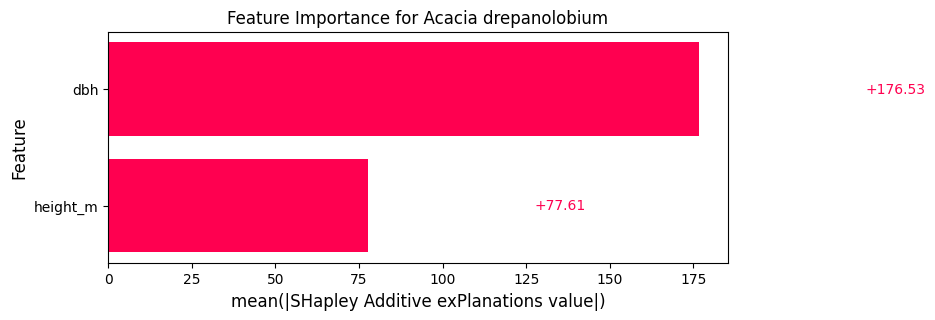

SHAP analysis completed for Acacia drepanolobium (GradientBoostingRegressor).

Acacia mearnsii (GradientBoostingRegressor) - RMSE: 73.3539, R²: 0.9957
Performing SHAP analysis for Acacia mearnsii (GradientBoostingRegressor)...


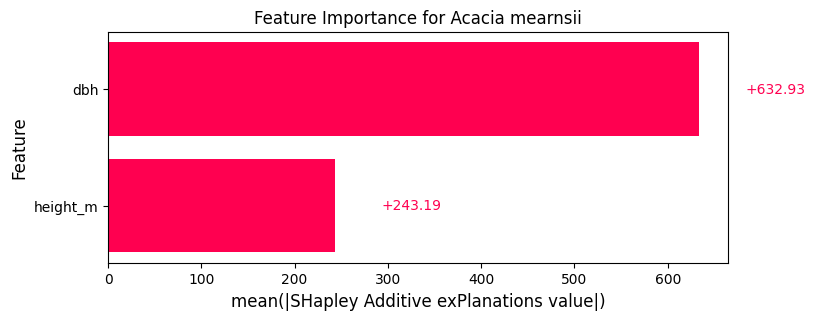

SHAP analysis completed for Acacia mearnsii (GradientBoostingRegressor).

Acacia mellifera (XGBRegressor) - RMSE: 89.0881, R²: 0.8268
Performing SHAP analysis for Acacia mellifera (XGBRegressor)...


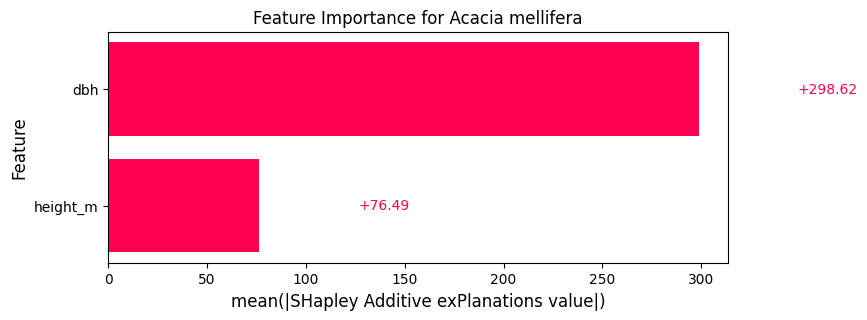

SHAP analysis completed for Acacia mellifera (XGBRegressor).

Acacia nilotica (XGBRegressor) - RMSE: 17.9297, R²: 0.9898
Performing SHAP analysis for Acacia nilotica (XGBRegressor)...


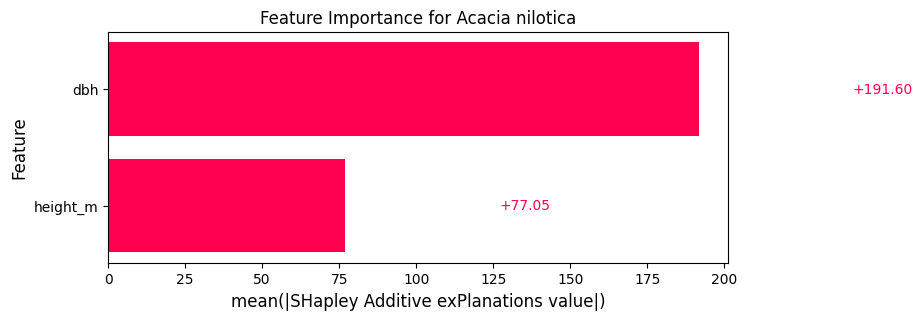

SHAP analysis completed for Acacia nilotica (XGBRegressor).

Acacia tortilis (XGBRegressor) - RMSE: 103.5523, R²: 0.9944
Performing SHAP analysis for Acacia tortilis (XGBRegressor)...


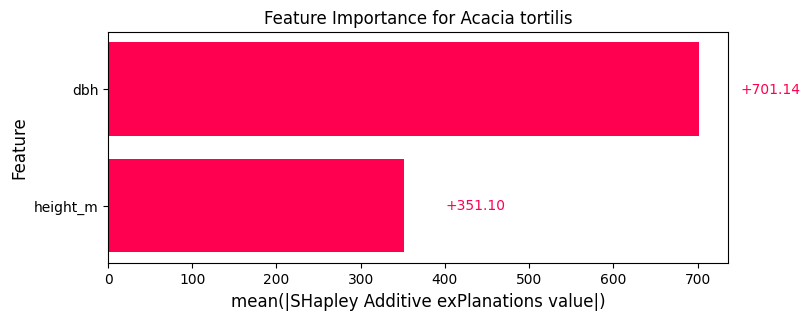

SHAP analysis completed for Acacia tortilis (XGBRegressor).

Acacia xanthophloea (RandomForestRegressor) - RMSE: 1486.4261, R²: 0.8008
Performing SHAP analysis for Acacia xanthophloea (RandomForestRegressor)...


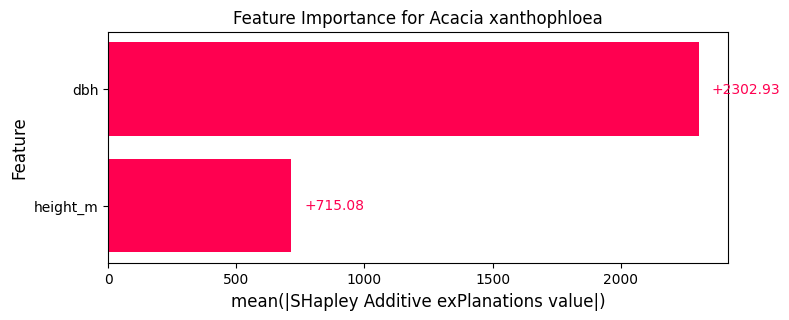

SHAP analysis completed for Acacia xanthophloea (RandomForestRegressor).



In [28]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define best hyperparameters for each species
best_params = {
    "Acacia drepanolobium": {"learning_rate": 0.2, "max_depth": 2, "max_features": 'sqrt', "min_samples_leaf": 2, "min_samples_split": 2, "n_estimators": 600, "subsample": 1.0},
    "Acacia mearnsii": {"learning_rate": 0.1, "max_depth": 5, "max_features": 'sqrt', "min_samples_leaf": 2, "min_samples_split": 5, "n_estimators": 200, "subsample": 0.8},
    "Acacia mellifera": {"colsample_bytree": 1, "learning_rate": 0.2, "max_depth": 3, "n_estimators": 1000, "reg_alpha": 0.01, "reg_lambda": 1, "subsample": 0.8},
    "Acacia nilotica": {"colsample_bytree": 1.0, "learning_rate": 0.1, "max_depth": 3, "n_estimators": 200, "reg_alpha": 0.1, "reg_lambda": 0, "subsample": 0.8},
    "Acacia tortilis": {"colsample_bytree": 1, "learning_rate": 0.05, "max_depth": 3, "n_estimators": 1000, "reg_alpha": 0.01, "reg_lambda": 1, "subsample": 0.8},
    "Acacia xanthophloea": {"bootstrap": True, "max_depth": 12, "max_features": 0.5, "min_samples_leaf": 1, "min_samples_split": 2, "n_estimators": 600}
}

# Loop through each species
df = acacia_df_cleaned_agb

for species, group in df.groupby('genus_species'):
    X = group[['dbh', 'height_m']]
    y = group['AGB']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Select model type based on species
    if species in ["Acacia drepanolobium", "Acacia mearnsii"]:
        model = GradientBoostingRegressor(**best_params[species], random_state=42)
        model_name = "GradientBoostingRegressor"
    elif species == "Acacia xanthophloea":
        model = RandomForestRegressor(**best_params[species], random_state=42)
        model_name = "RandomForestRegressor"
    else:
        model = XGBRegressor(**best_params[species], random_state=42)
        model_name = "XGBRegressor"

    model.fit(X_train, y_train)

    # Model evaluation
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{species} ({model_name}) - RMSE: {rmse:.4f}, R²: {r2:.4f}")

    ### SHAP ANALYSIS (Model-Specific) ###
    print(f"Performing SHAP analysis for {species} ({model_name})...")

    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_test)

    # Compute mean absolute SHAP values
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

    # Plot absolute mean SHAP value bar chart with custom colors
    plt.figure(figsize=(8, 3))
    colors = ["#FF0050"] * len(mean_abs_shap)  # Matching color from the image

    plt.barh(X.columns, mean_abs_shap, color=colors)
    plt.xlabel("mean(|SHapley Additive exPlanations value|)", fontsize=12)
    plt.ylabel("Feature", fontsize=12)
    plt.title(f"Feature Importance for {species}", fontsize=12)
    plt.gca().invert_yaxis()

    # Annotate the values
    for i, v in enumerate(mean_abs_shap):
        plt.text(v + 50, i, f"+{v:.2f}", color=colors[i], fontsize=10, va='center')

    plt.show()

    print(f"SHAP analysis completed for {species} ({model_name}).\n")

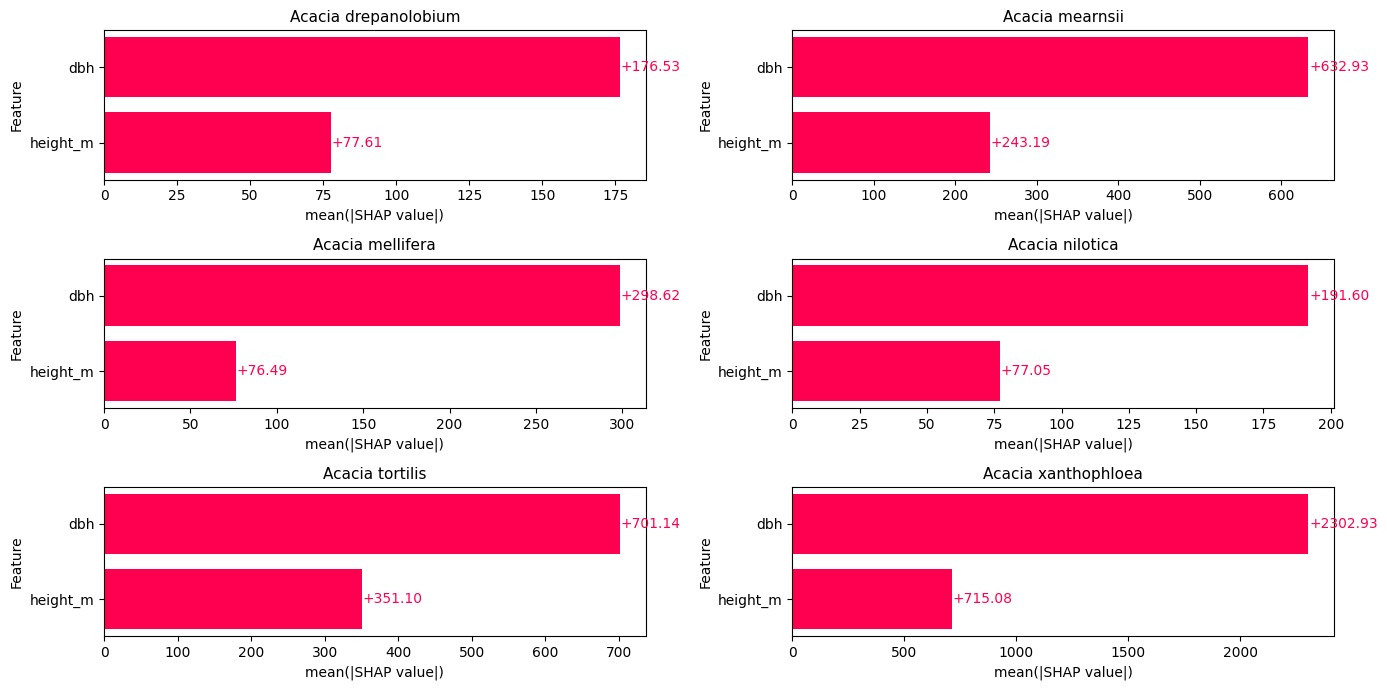

In [35]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# Best hyperparameters per species
# -----------------------------
best_params = {
    "Acacia drepanolobium": {
        "learning_rate": 0.2, "max_depth": 2, "max_features": 'sqrt',
        "min_samples_leaf": 2, "min_samples_split": 2,
        "n_estimators": 600, "subsample": 1.0
    },
    "Acacia mearnsii": {
        "learning_rate": 0.1, "max_depth": 5, "max_features": 'sqrt',
        "min_samples_leaf": 2, "min_samples_split": 5,
        "n_estimators": 200, "subsample": 0.8
    },
    "Acacia mellifera": {
        "colsample_bytree": 1, "learning_rate": 0.2, "max_depth": 3,
        "n_estimators": 1000, "reg_alpha": 0.01,
        "reg_lambda": 1, "subsample": 0.8
    },
    "Acacia nilotica": {
        "colsample_bytree": 1.0, "learning_rate": 0.1,
        "max_depth": 3, "n_estimators": 200,
        "reg_alpha": 0.1, "reg_lambda": 0,
        "subsample": 0.8
    },
    "Acacia tortilis": {
        "colsample_bytree": 1, "learning_rate": 0.05,
        "max_depth": 3, "n_estimators": 1000,
        "reg_alpha": 0.01, "reg_lambda": 1,
        "subsample": 0.8
    },
    "Acacia xanthophloea": {
        "bootstrap": True, "max_depth": 12,
        "max_features": 0.5, "min_samples_leaf": 1,
        "min_samples_split": 2, "n_estimators": 600
    }
}

# -----------------------------
# Data and species list
# -----------------------------
df = acacia_df_cleaned_agb
species_list = list(best_params.keys())

# -----------------------------
# Fixed grid layout: 3 rows x 2 columns
# -----------------------------
rows, cols = 3, 2
fig, axes = plt.subplots(rows, cols, figsize=(14, 7))
axes = axes.flatten()

# -----------------------------
# Loop through species
# -----------------------------
for i, species in enumerate(species_list):
    group = df[df['genus_species'] == species]

    X = group[['dbh', 'height_m']]
    y = group['AGB']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # -------------------------
    # Model selection
    # -------------------------
    if species in ["Acacia drepanolobium", "Acacia mearnsii"]:
        model = GradientBoostingRegressor(
            **best_params[species], random_state=42
        )
    elif species == "Acacia xanthophloea":
        model = RandomForestRegressor(
            **best_params[species], random_state=42, n_jobs=-1
        )
    else:
        model = XGBRegressor(
            **best_params[species],
            random_state=42,
            objective="reg:squarederror",
            n_jobs=-1
        )

    model.fit(X_train, y_train)

    # -------------------------
    # SHAP computation
    # -------------------------
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_test)

    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

    # -------------------------
    # Plot
    # -------------------------
    ax = axes[i]
    bar_color = "#FF0050"

    ax.barh(
        X.columns,
        mean_abs_shap,
        color=[bar_color] * len(mean_abs_shap)
    )

    ax.set_xlabel("mean(|SHAP value|)", fontsize=10)
    ax.set_ylabel("Feature", fontsize=10)
    ax.set_title(species, fontsize=11)
    ax.invert_yaxis()

    # Value annotations
    for j, v in enumerate(mean_abs_shap):
        ax.text(
            v * 1.002,
            j,
            f"+{v:.2f}",
            fontsize=10,
            color=bar_color,
            va="center"
        )

# -----------------------------
# Remove unused axes (safety)
# -----------------------------
for j in range(len(species_list), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Acacia drepanolobium (GradientBoostingRegressor) - RMSE: 26.8658, R²: 0.9890
Performing SHAP analysis for Acacia drepanolobium (GradientBoostingRegressor)...


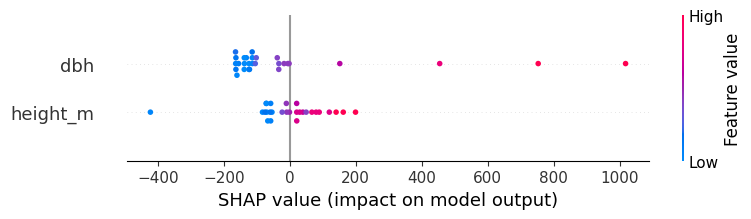

SHAP analysis completed for Acacia drepanolobium (GradientBoostingRegressor).

Acacia mearnsii (GradientBoostingRegressor) - RMSE: 73.3539, R²: 0.9957
Performing SHAP analysis for Acacia mearnsii (GradientBoostingRegressor)...


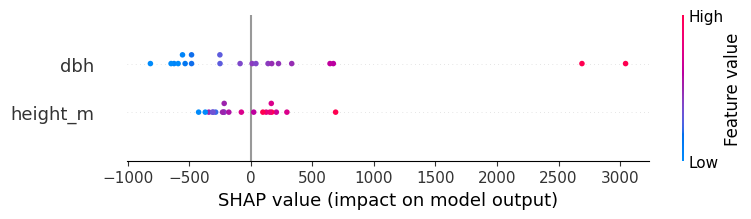

SHAP analysis completed for Acacia mearnsii (GradientBoostingRegressor).

Acacia mellifera (XGBRegressor) - RMSE: 89.0881, R²: 0.8268
Performing SHAP analysis for Acacia mellifera (XGBRegressor)...


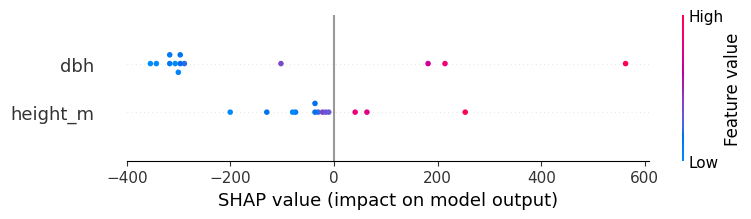

SHAP analysis completed for Acacia mellifera (XGBRegressor).

Acacia nilotica (XGBRegressor) - RMSE: 17.9297, R²: 0.9898
Performing SHAP analysis for Acacia nilotica (XGBRegressor)...


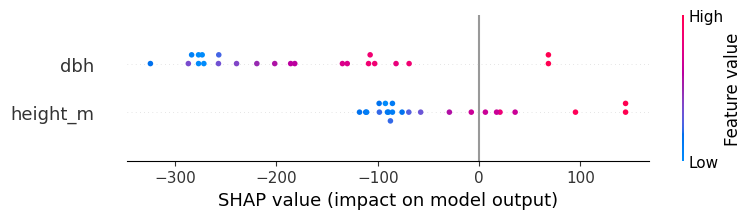

SHAP analysis completed for Acacia nilotica (XGBRegressor).

Acacia tortilis (XGBRegressor) - RMSE: 103.5523, R²: 0.9944
Performing SHAP analysis for Acacia tortilis (XGBRegressor)...


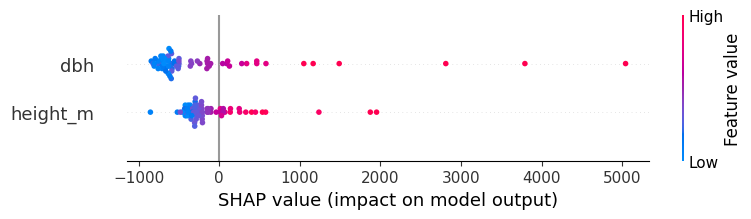

SHAP analysis completed for Acacia tortilis (XGBRegressor).

Acacia xanthophloea (RandomForestRegressor) - RMSE: 1486.4261, R²: 0.8008
Performing SHAP analysis for Acacia xanthophloea (RandomForestRegressor)...


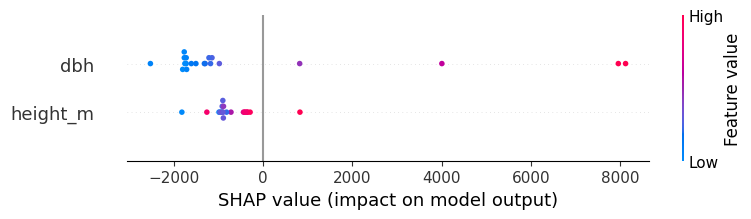

SHAP analysis completed for Acacia xanthophloea (RandomForestRegressor).



In [36]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define best hyperparameters for each species
best_params = {
    "Acacia drepanolobium": {"learning_rate": 0.2, "max_depth": 2, "max_features": 'sqrt', "min_samples_leaf": 2, "min_samples_split": 2, "n_estimators": 600, "subsample": 1.0},
    "Acacia mearnsii": {"learning_rate": 0.1, "max_depth": 5, "max_features": 'sqrt', "min_samples_leaf": 2, "min_samples_split": 5, "n_estimators": 200, "subsample": 0.8},
    "Acacia mellifera": {"colsample_bytree": 1, "learning_rate": 0.2, "max_depth": 3, "n_estimators": 1000, "reg_alpha": 0.01, "reg_lambda": 1, "subsample": 0.8},
    "Acacia nilotica": {"colsample_bytree": 1.0, "learning_rate": 0.1, "max_depth": 3, "n_estimators": 200, "reg_alpha": 0.1, "reg_lambda": 0, "subsample": 0.8},
    "Acacia tortilis": {"colsample_bytree": 1, "learning_rate": 0.05, "max_depth": 3, "n_estimators": 1000, "reg_alpha": 0.01, "reg_lambda": 1, "subsample": 0.8},
    "Acacia xanthophloea": {"bootstrap": True, "max_depth": 12, "max_features": 0.5, "min_samples_leaf": 1, "min_samples_split": 2, "n_estimators": 600}
}

# Loop through each species
df = acacia_df_cleaned_agb

for species, group in df.groupby('genus_species'):
    X = group[['dbh', 'height_m']]
    y = group['AGB']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Select model type based on species
    if species in ["Acacia drepanolobium", "Acacia mearnsii"]:
        model = GradientBoostingRegressor(**best_params[species], random_state=42)
        model_name = "GradientBoostingRegressor"
    elif species == "Acacia xanthophloea":
        model = RandomForestRegressor(**best_params[species], random_state=42)
        model_name = "RandomForestRegressor"
    else:
        model = XGBRegressor(**best_params[species], random_state=42)
        model_name = "XGBRegressor"

    model.fit(X_train, y_train)

    # Model evaluation
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{species} ({model_name}) - RMSE: {rmse:.4f}, R²: {r2:.4f}")

    ### SHAP ANALYSIS (Model-Specific) ###
    print(f"Performing SHAP analysis for {species} ({model_name})...")

    if model_name == "RandomForestRegressor":
        explainer = shap.TreeExplainer(model)  # Use TreeExplainer for tree-based models
    else:
        explainer = shap.Explainer(model, X_train)  # Default explainer for other models

    shap_values = explainer(X_test)  # Compute SHAP values

    # Convert DataFrame to numpy if needed
    X_test_array = X_test.to_numpy() if isinstance(X_test, pd.DataFrame) else X_test

    ## SHAP PLOTS ##
    # 1. Summary Plot (Feature Importance)
    shap.summary_plot(shap_values, X_test_array, feature_names=X.columns)


    print(f"SHAP analysis completed for {species} ({model_name}).\n")
